# RQ3 — SE Tools and Techniques Applied in Data Science Projects

**RQ3:** *What software engineering tools and techniques have been applied to develop and maintain data science applications?*

**Analyses:**
1. SE tool category adoption rates and mean usefulness scores
2. SE practice current adoption rates (ranked)
3. SE adoption score distribution and bimodal analysis
4. Spearman correlation: SE/DS experience vs adoption score
5. Kruskal-Wallis: adoption score ~ role, org type, DS framework knowledge
6. Per-group descriptives for significant predictor (DS framework knowledge)


In [1]:
!pip install matplotlib

zsh:1: /Users/chaiyong/Downloads/do_not_delete/2023_SE4DS/EMSE/.venv/bin/pip: bad interpreter: /Users/chaiyong/Downloads/2023_SE4DS/EMSE/.venv/bin/python3.13: no such file or directory


In [2]:
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from analysis_utils import load_data, RATING_COLS, METHOD_COLS, CURRENT_TH

warnings.filterwarnings('ignore')
df = load_data()
N  = len(df)
print(f"Dataset loaded: {N} respondents")

Dataset loaded: 112 respondents


## 1. SE Tool Category Adoption & Usefulness Ratings

In [3]:
rows = []
for c, label in RATING_COLS.items():
    used_col = c + '_used'
    num_col  = c + '_num'
    if used_col not in df.columns:
        continue
    n_used   = int(df[used_col].sum())
    pct_used = round(n_used / N * 100, 1)
    ratings  = df[num_col].dropna()
    mean_r   = round(ratings.mean(), 2) if len(ratings) > 0 else float('nan')
    med_r    = ratings.median()         if len(ratings) > 0 else float('nan')
    rows.append({
        'Tool Category':  label,
        'n used':         n_used,
        '% used':         pct_used,
        'Mean rating':    mean_r,
        'Median rating':  med_r,
    })

tool_df = pd.DataFrame(rows).sort_values('% used', ascending=False).reset_index(drop=True)
display(tool_df)

,Tool Category,n used,% used,Mean rating,Median rating
0,Knowledge management tools,68,60.7,4.00,4.0
1,Config. management tools,66,58.9,4.02,4.0
2,Meeting tools,65,58.0,4.05,5.0
3,Construction tools,64,57.1,4.33,5.0
4,Social/collaboration tools,62,55.4,3.79,4.0
5,SE management tools,61,54.5,3.80,4.0
6,Testing tools,58,51.8,3.78,4.0
7,Miscellaneous tools,57,50.9,3.95,4.0
8,Maintenance tools,45,40.2,3.44,4.0
9,Quality tools,45,40.2,3.56,4.0


## 2. SE Practice Current Adoption Rates

In [4]:
method_rows = []
for c, label in METHOD_COLS.items():
    if c not in df.columns:
        continue
    curr = int((df[c] == CURRENT_TH).sum())
    past = int(df[c + '_past'].sum()) if c + '_past' in df.columns else 0
    plan = int(df[c + '_plan'].sum()) if c + '_plan' in df.columns else 0
    method_rows.append({
        'Practice':        label,
        'Current (n)':     curr,
        'Current (%)':     round(curr / N * 100, 1),
        'Past use (n)':    past,
        'Plan to use (n)': plan,
    })

meth_df = pd.DataFrame(method_rows).sort_values('Current (%)', ascending=False).reset_index(drop=True)
display(meth_df)

,Practice,Current (n),Current (%),Past use (n),Plan to use (n)
0,Model testing,43,38.4,4,11
1,Scrum/Kanban,40,35.7,12,10
2,Code review,40,35.7,8,12
3,Daily stand-up meetings,38,33.9,13,8
4,Use case / user story,37,33.0,10,10
5,Unit testing,36,32.1,11,11
6,Containerisation,34,30.4,8,17
7,Sprint/iteration planning,33,29.5,9,13
8,Requirements analysis,33,29.5,9,14
9,Integration testing,32,28.6,6,18


## 3. SE Adoption Score Distribution

In [5]:
score = df['adoption_score']

summary = pd.DataFrame([{
    'Mean':              round(score.mean(), 2),
    'Median':            score.median(),
    'SD':                round(score.std(), 2),
    'Min':               int(score.min()),
    'Max':               int(score.max()),
    'Non-adopters (=0)': f"{int((score==0).sum())} ({(score==0).sum()/N*100:.1f}%)",
    'Partial (1–7)':     f"{int(((score>=1)&(score<=7)).sum())} ({((score>=1)&(score<=7)).sum()/N*100:.1f}%)",
    'High (≥8)':         f"{int((score>=8).sum())} ({(score>=8).sum()/N*100:.1f}%)",
}])
display(summary.T.rename(columns={0: 'Value'}))

,Value
Mean,4.59
Median,3.5
SD,4.82
Min,0
Max,15
Non-adopters (=0),47 (42.0%)
Partial (1–7),28 (25.0%)
High (≥8),37 (33.0%)


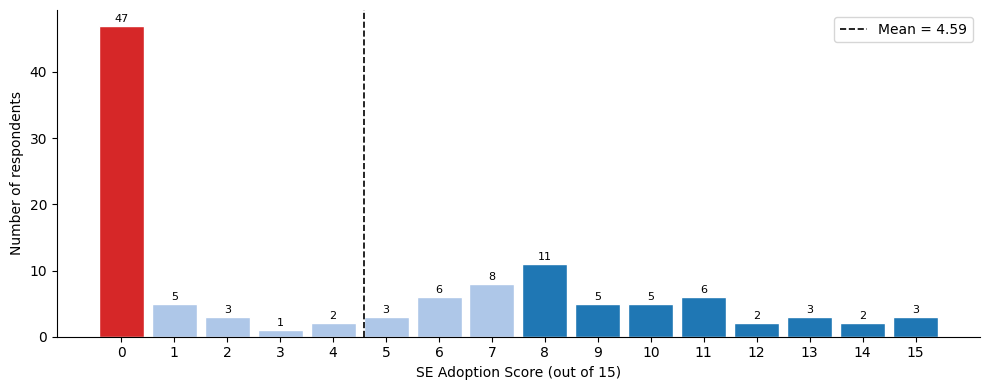

In [6]:
# Histogram
bar_colors = ['#d62728' if s == 0 else '#aec7e8' if s <= 7 else '#1f77b4' for s in range(16)]
counts = [int((score == s).sum()) for s in range(16)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(16), counts, color=bar_colors, edgecolor='white', width=0.85)
for s, cnt in enumerate(counts):
    if cnt > 0:
        ax.text(s, cnt + 0.3, str(cnt), ha='center', va='bottom', fontsize=8)
ax.axvline(score.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Mean = {score.mean():.2f}')
ax.set_xlabel('SE Adoption Score (out of 15)')
ax.set_ylabel('Number of respondents')
ax.set_xticks(range(16))
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Spearman Correlation: Experience vs Adoption Score

In [7]:
corr_rows = []
for exp_col, label in [('se_exp', 'SE experience'), ('ds_exp', 'DS experience')]:
    tmp = df[[exp_col, 'adoption_score']].dropna()
    rho, p = stats.spearmanr(tmp[exp_col], tmp['adoption_score'])
    corr_rows.append({
        'Experience':   label,
        'rho':          round(rho, 3),
        'p-value':      round(p, 4),
        'Sig. (p<.05)': '*' if p < 0.05 else '',
    })

display(pd.DataFrame(corr_rows))

,Experience,rho,p-value,Sig. (p<.05)
0,SE experience,0.247,0.0087,*
1,DS experience,0.086,0.3684,


## 5. Kruskal-Wallis: Adoption Score ~ Grouping Variables

In [8]:
grouping_vars = {
    'role':                        'Practitioner role',
    'organization_type_Response':  'Organisation type',
    'knows_ds_framework_Response': 'DS framework knowledge',
}

kw_rows = []
for col, label in grouping_vars.items():
    if col not in df.columns:
        continue
    groups = [g['adoption_score'].values for _, g in df.groupby(col) if len(g) >= 3]
    if len(groups) < 2:
        continue
    h, p = stats.kruskal(*groups)
    kw_rows.append({
        'Grouping variable': label,
        'H-Statistic':       round(h, 3),
        'p-value':           round(p, 4),
        'Sig. (p<.05)':      '*' if p < 0.05 else '',
    })

display(pd.DataFrame(kw_rows))

,Grouping variable,H-Statistic,p-value,Sig. (p<.05)
0,Practitioner role,7.071,0.3144,
1,Organisation type,3.781,0.2861,
2,DS framework knowledge,5.461,0.0652,


## 6. Per-Group Descriptives: DS Framework Knowledge (significant predictor)

In [9]:
fw_labels = {
    'รู้จักและใช้งาน':         'Knows and uses a DS framework',
    'รู้จักแต่ไม่ได้ใช้งาน': 'Knows but does not use',
    'ไม่รู้จัก':              'Unfamiliar with DS frameworks',
}

fw_col = 'knows_ds_framework_Response'
fw_rows = []
for val, label in fw_labels.items():
    grp = df[df[fw_col] == val]['adoption_score']
    if len(grp) == 0:
        continue
    fw_rows.append({
        'DS Framework Knowledge': label,
        'n':                      len(grp),
        'Mean adoption score':    round(grp.mean(), 2),
        'Median':                 grp.median(),
    })

display(pd.DataFrame(fw_rows))

,DS Framework Knowledge,n,Mean adoption score,Median
0,Knows and uses a DS framework,48,5.35,6.5
1,Knows but does not use,33,5.03,4.0
2,Unfamiliar with DS frameworks,31,2.94,0.0
